### 1) Import Pandas and Numpy

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 2) Import the dataset and  Assign it to a variable called Chipo

#### Import the dataset from
https://github.com/justmarkham/pandas-videos/blob/master/data/chipotle.tsv

#### REMEMBER: It is a .tsv file , you will have to do some research on how to read .tsv files first!

In [66]:
chipo= pd.read_table('https://raw.githubusercontent.com/justmarkham/pandas-videos/refs/heads/master/data/chipotle.tsv')

### 3) See the first 10 entries

In [67]:
chipo.head(10)

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",$10.98
6,3,1,Side of Chips,NaN,$1.69
7,4,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",$11.75
8,4,1,Steak Soft Tacos,"[Tomatillo Green Chili Salsa, [Pinto Beans, Ch...",$9.25
9,5,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Pinto...",$9.25


### 4) What is the number of observations in the dataset?

In [68]:
chipo.shape[0]

4622

### 5) What is the number of columns in the dataset?

In [69]:
chipo.shape[1]

5

### 6) Print the name of all the columns.

In [70]:
chipo.columns

Index(['order_id', 'quantity', 'item_name', 'choice_description',
       'item_price'],
      dtype='object')

### 7) Which was the most-ordered item?

In [71]:
chipo.groupby("item_name")["quantity"].sum().idxmax()

'Chicken Bowl'

### 8) For the most-ordered item, how many items were ordered?

In [72]:
chipo.quantity[chipo.item_name=="Chicken Bowl"].sum()

np.int64(761)

### 9) What was the most ordered item in the choice_description column?

In [73]:
chipo.choice_description.value_counts().idxmax()

'[Diet Coke]'

### 10) How many items were ordered in total?

In [74]:
chipo.quantity.sum()

np.int64(4972)

### 11) Turn the item price into a float

In [75]:
chipo.item_price =chipo.item_price.map(lambda x : x.replace("$", "")).astype(float)

### 12) How much was the revenue for the period in the dataset?
#### Revenue will be the sum of quantity * item_price!

In [76]:
chipo.item_price.mul(chipo.quantity).sum()

np.float64(39237.02)

### 13) How many orders were made in the period?

In [77]:
chipo.order_id.unique().shape[0]

1834

### 14) What is the average revenue amount per order?

In [78]:
chipo["total"] = chipo.item_price*chipo.quantity

In [82]:
(chipo.groupby("order_id")["total"].sum()).mean()

np.float64(21.39423118865867)

### 15) How many different items are sold?

In [83]:
chipo.item_name.unique().shape[0]

50

### 16) Show a histogram with number of orders with bill on the x-axis.

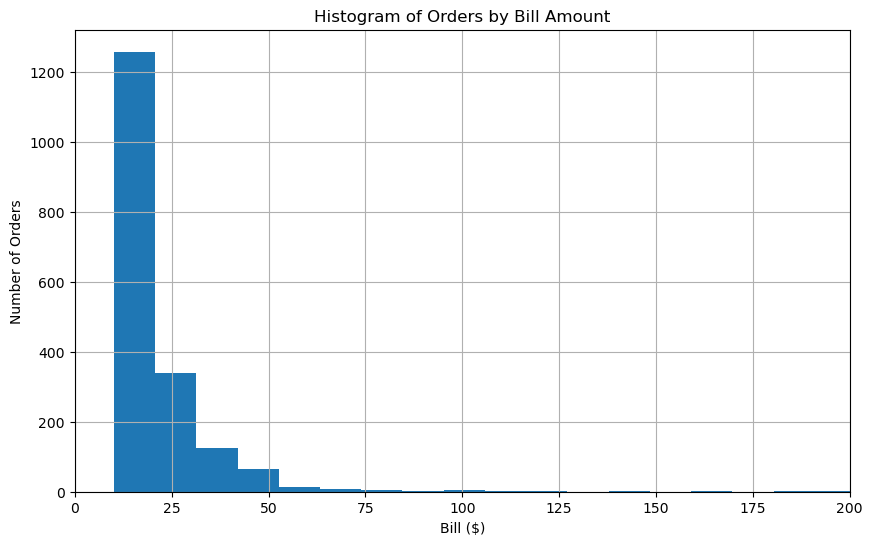

In [96]:
order_total = chipo.groupby("order_id")["total"].sum()
order_total.hist(bins=100,figsize=(10,6))
plt.xlim(0, 200) 
plt.xlabel("Bill ($)")
plt.ylabel("Number of Orders")
plt.title("Histogram of Orders by Bill Amount")
plt.show()